In [ ]:

# IMPORTAR LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from datetime import datetime
import chardet
import unicodedata
import re
import pyodbc


###### ============================================================
#### 1.1 CARGA DEL ARCHIVO
###### ============================================================

In [67]:
#lecturaurl = "https://raw.githubusercontent.com/Javierff1985/TFM/main/ArchivoBeneficiariosInicial_.csv"

url = "https://raw.githubusercontent.com/Javierff1985/TFM/main/ArchivoBeneficiariosInicial_.csv"
df = pd.read_csv(url, sep=';', encoding='latin1')  
print(df.head())


       ID  DIVIPOLAMUNICIPIO      DEPARTAMENTOMUNICIPIO   VEREDA URBANO_RURAL  \
0  221729              47703  47703-MAGDALENA-SAN ZENÓN  JANEIRO        RURAL   
1  221730              47703  47703-MAGDALENA-SAN ZENÓN  JANEIRO        RURAL   
2  221731              47703  47703-MAGDALENA-SAN ZENÓN  JANEIRO        RURAL   
3  221732              47703  47703-MAGDALENA-SAN ZENÓN  JANEIRO        RURAL   
4  221733              47703  47703-MAGDALENA-SAN ZENÓN  JANEIRO        RURAL   

  LINEADEPROGRAMA UNIVERSIDADEJECUTORA          RUTADEEXPERIENCIA  \
0            PSCP           UATLANTICO  MÚSICAS VOCALES Y CORALES   
1            PSCP           UATLANTICO  MÚSICAS VOCALES Y CORALES   
2            PSCP           UATLANTICO  MÚSICAS VOCALES Y CORALES   
3            PSCP           UATLANTICO  MÚSICAS VOCALES Y CORALES   
4            PSCP           UATLANTICO  MÚSICAS VOCALES Y CORALES   

  CODIGODANEEE                                           NOMBREEE  ...  \
0  2,47703E+11  INSTITUC

In [ ]:
ruta = "C:/Users/Computer User/OneDrive/TFM/ArchivoBeneficiariosInicial_.csv"

# Detectar encoding
with open(ruta, "rb") as f:
    encoding_detectado = chardet.detect(f.read(50000))["encoding"]
print("Encoding detectado:", encoding_detectado)
# Cargar CSV correctamente
df = pd.read_csv(
    ruta,
    encoding='latin1',
    sep=';',
    engine='python',
    on_bad_lines='skip',
    na_values=["", "NA", "N/A", "null", None]
)
df.columns = df.columns.str.replace('ï»¿', '', regex=False)

# Renombrar ID correctamente
df = df.rename(columns={'ID': 'id'})
df.columns = (
    df.columns
    .str.replace('ï»¿', '', regex=False)   # elimina BOM
    .str.strip()                           # elimina espacios
    .str.lower()                           # pasa todo a minúsculas
)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
df.head()
       

###### ============================================================
#### 1.2 INFORMACIÓN GENERAL DEL DATASET
###### ============================================================

In [68]:
print("\n--- INFO GENERAL ---")
df.info()
print("\n--- TIPOS DE DATOS ---")
print(df.dtypes)
print("\n--- ESTADÍSTICAS NUMÉRICAS ---")
display(df.describe())
print("\n--- ESTADÍSTICAS CATEGÓRICAS ---")
display(df.describe(include='object'))


--- INFO GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20377 entries, 0 to 20376
Data columns (total 28 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   ID                                                           20377 non-null  int64  
 1   DIVIPOLAMUNICIPIO                                            20377 non-null  int64  
 2   DEPARTAMENTOMUNICIPIO                                        20377 non-null  object 
 3   VEREDA                                                       13465 non-null  object 
 4   URBANO_RURAL                                                 20377 non-null  object 
 5   LINEADEPROGRAMA                                              20377 non-null  object 
 6   UNIVERSIDADEJECUTORA                                         20377 non-null  object 
 7   RUTADEEXPERIENCIA                                     

,ID,DIVIPOLAMUNICIPIO,CAMPESINO,POBLACIONMIGRANTE,ELESTUDIANTEREQUIEREALIMENTACIONPRAASISTIRALCENTRODEINTERES,ELESTUDIANTEREQUIERETRANSPORTEPARAASISTERALCENTRODEINTERES,ANIO,CENTROINTERES
count,20377.000000,20377.000000,20377.000000,20377.000000,20377.000000,20377.000000,20377.0,0.0
mean,232490.660794,41057.132110,0.305344,0.040978,0.528733,0.342003,2025.0,NaN
std,6817.583524,26516.268555,0.460564,0.198243,0.499186,0.474392,0.0,NaN
min,221729.000000,8001.000000,0.000000,0.000000,0.000000,0.000000,2025.0,NaN
25%,226832.000000,17042.000000,0.000000,0.000000,0.000000,0.000000,2025.0,NaN
50%,231932.000000,44855.000000,0.000000,0.000000,1.000000,0.000000,2025.0,NaN
75%,237095.000000,66594.000000,1.000000,0.000000,1.000000,1.000000,2025.0,NaN
max,246806.000000,86885.000000,1.000000,1.000000,1.000000,1.000000,2025.0,NaN



--- ESTADÍSTICAS CATEGÓRICAS ---


,DEPARTAMENTOMUNICIPIO,VEREDA,URBANO_RURAL,LINEADEPROGRAMA,UNIVERSIDADEJECUTORA,RUTADEEXPERIENCIA,CODIGODANEEE,NOMBREEE,CODIGODANESEDEEE,NOMBRESEDEEE,TIPOPERSONA,TIPODOCUMENTO,NUMERODOCUMENTO,SEXO,FECHANACIMIENTODDMMAAAA,PERTENENCIAETNICA,PERSONACONDISCAPACIDAD,GRADOESCOLAR,FECHAREGISRO,PLANEACIION
count,20377,13465,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377,20377
unique,123,590,4,1,4,10,162,216,170,328,1,11,18254,2,4920,7,10,19,19,1
top,18247-CAQUETÁ-EL DONCELLO,NO APLICA,URBANO,PSCP,UATLANTICO,MÚSICAS POPULARES TRADICIONALES,"1,27361E+11",I.E. MARCO FIDEL SUAREZ,"1,27361E+11",COL FRANCISCO DE PAULA SANTANDER,PERSONA NATURAL,NUIP (MENORES DE EDAD),"4,00E+09",MASCULINO,2012-10-01 00:00:00.0000000,NINGÚN GRUPO ÉTNICO,NO,6,21/03/2025,ENVIADO
freq,613,1413,11611,20377,7317,6896,447,313,447,306,20377,18285,85,10295,19,16745,20094,3274,4327,20377


###### ============================================================
##### 1.3 VALORES FALTANTES
###### ============================================================

,Valores Faltantes,% Faltantes
CENTROINTERES,20377,100.000000
VEREDA,6912,33.920597
DIVIPOLAMUNICIPIO,0,0.000000
ID,0,0.000000
URBANO_RURAL,0,0.000000
LINEADEPROGRAMA,0,0.000000
UNIVERSIDADEJECUTORA,0,0.000000
RUTADEEXPERIENCIA,0,0.000000
CODIGODANEEE,0,0.000000
NOMBREEE,0,0.000000


C:\Users\Computer User\AppData\Local\Temp\ipykernel_24384\3407514315.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=porcentaje[:20], y=porcentaje.index[:20], palette="viridis")


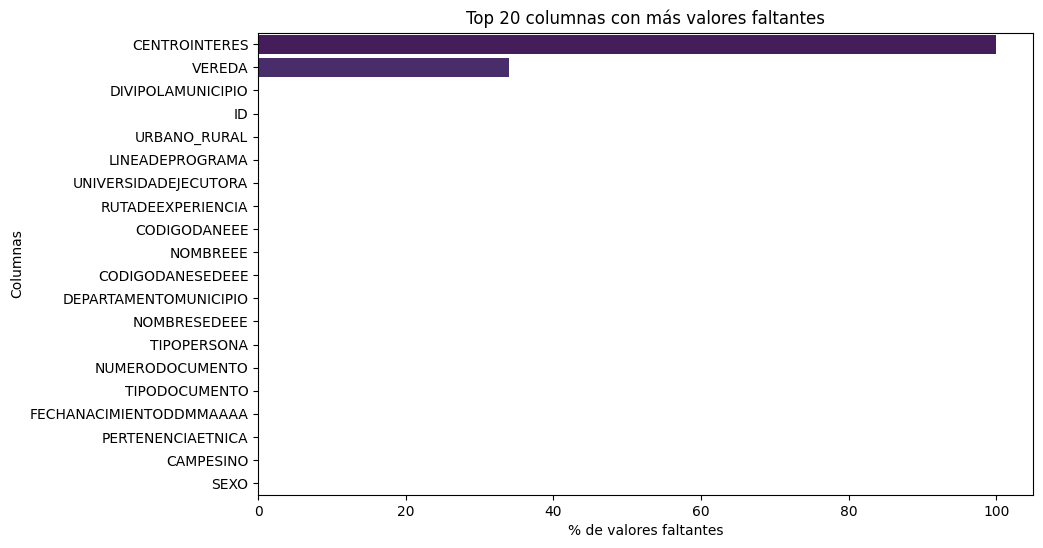

In [69]:
faltantes = df.isnull().sum().sort_values(ascending=False)
porcentaje = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Valores Faltantes': faltantes,
    '% Faltantes': porcentaje
})
display(missing_df)
plt.figure(figsize=(10,6))
sns.barplot(x=porcentaje[:20], y=porcentaje.index[:20], palette="viridis")
plt.title("Top 20 columnas con más valores faltantes")
plt.xlabel("% de valores faltantes")
plt.ylabel("Columnas")
plt.show()

###### ============================================================
#### 1.3 UNIFICAR TERMINOS
###### ============================================================

In [70]:
#aca se busca que eliminar vacios y unificar terminos para que el dato sea homogeneo y convertir todo a mayusculas para mejorar la lectura de los datos
cols_obj = df.select_dtypes(include=['object']).columns
for col in cols_obj:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()      
        .str.upper()      
    )

###### ============================================================
#### 1.4 DUPLICADOS
###### ============================================================

In [71]:
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


###### ============================================================
#### 1.6 BOXPLOTS PARA DETECCIÓN DE OUTLIERS
###### ============================================================

In [ ]:

#el archivo no contiene valores numericos para el uso de boxplot

#cols_num = df.select_dtypes(include=['int64', 'float64']).columns
#for col in cols_num:
#    plt.figure(figsize=(6,4))
#    sns.boxplot(data=df, y=col, color='tomato')
#    plt.title(f"Boxplot de {col}", fontsize=14)
#    plt.ylabel("")
#    plt.tight_layout()
#    plt.show()


###### ============================================================
#### 1.7 CORRELACIONES
###### ============================================================

In [ ]:
#no se ejecuta por no terner variable numericas para calculos

#cols_num = df.select_dtypes(include=['int64', 'float64']).columns
#plt.figure(figsize=(12,8))
#sns.heatmap(df[cols_num].corr(), annot=False, cmap='coolwarm')
#plt.title("Matriz de correlación")
#plt.show()


###### ============================================================
#### 1.8 ANÁLISIS DE VARIABLES CATEGÓRICAS
###### ============================================================

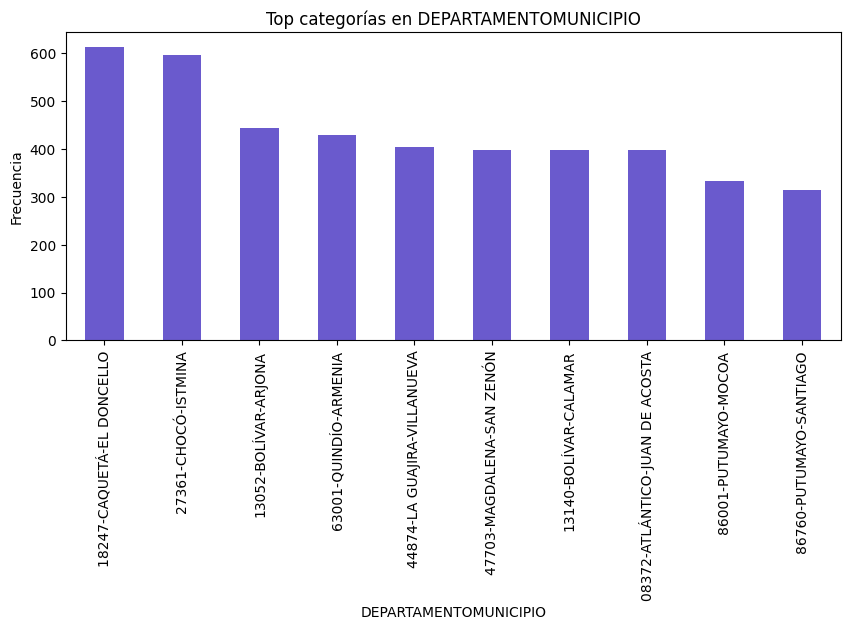

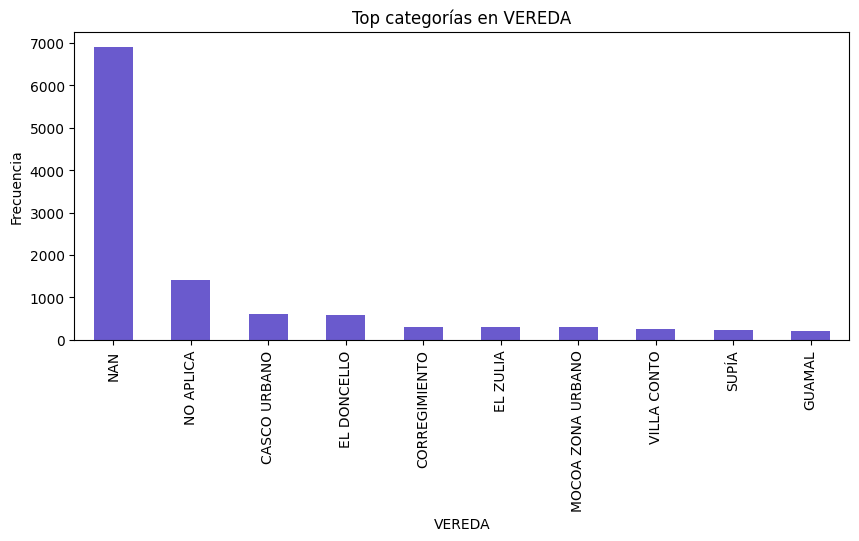

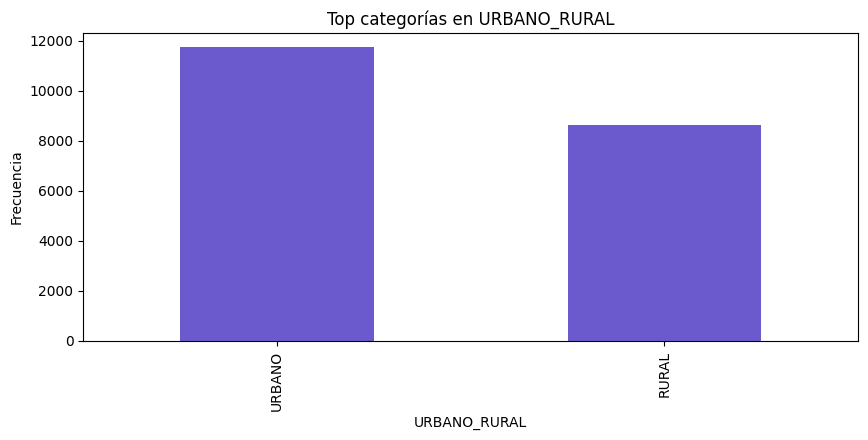

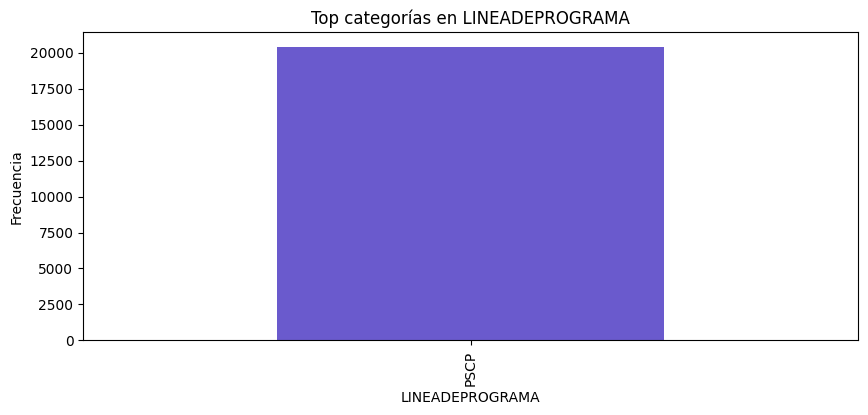

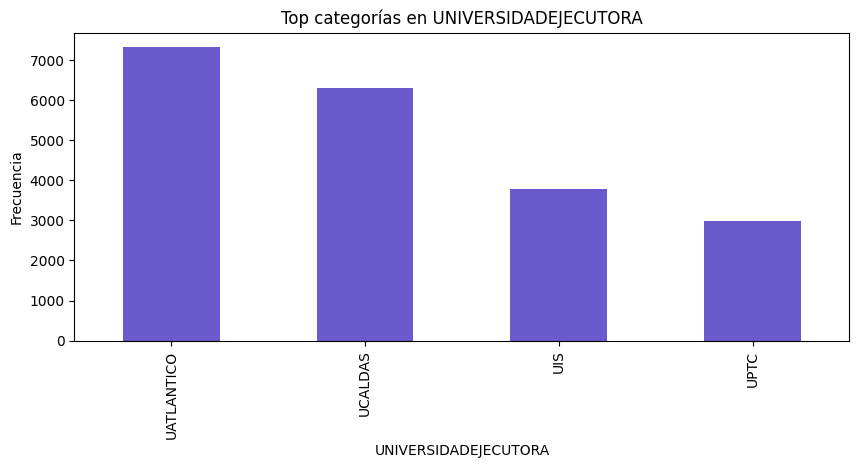

C:\Users\Computer User\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


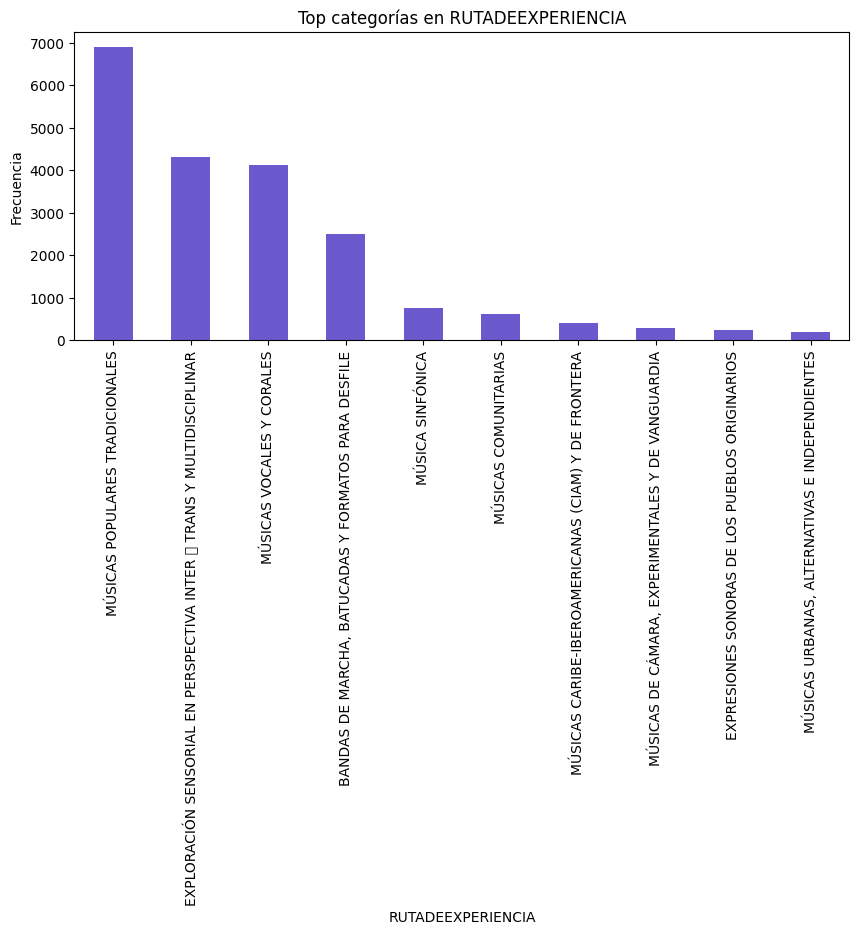

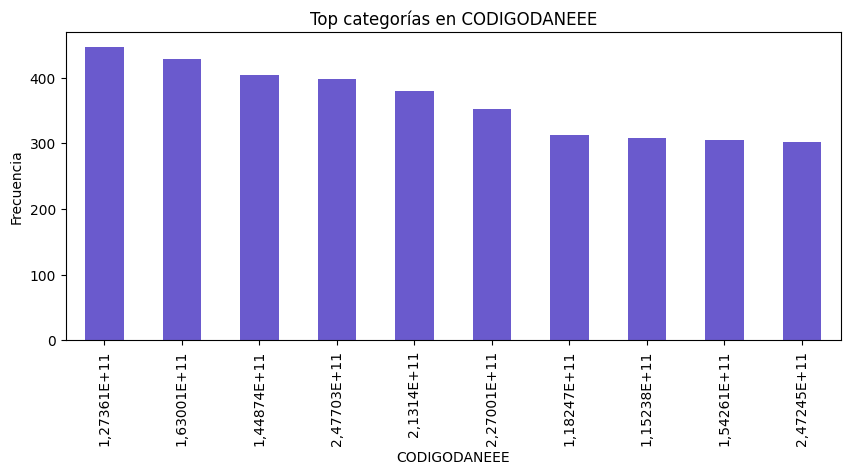

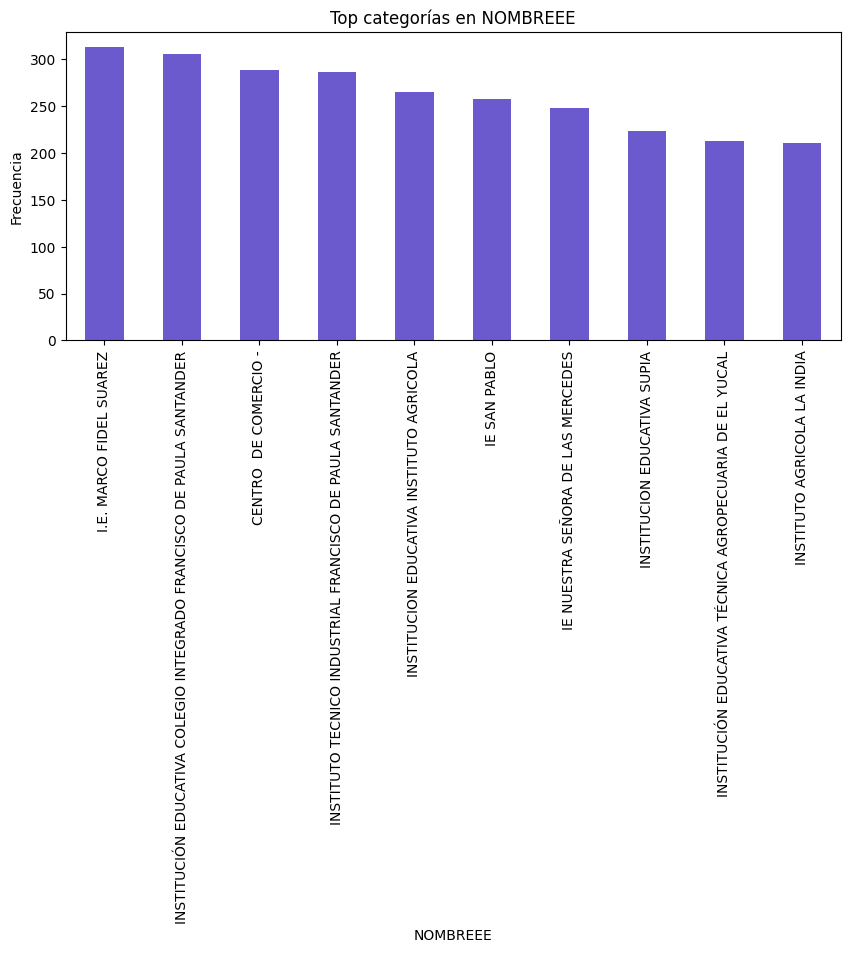

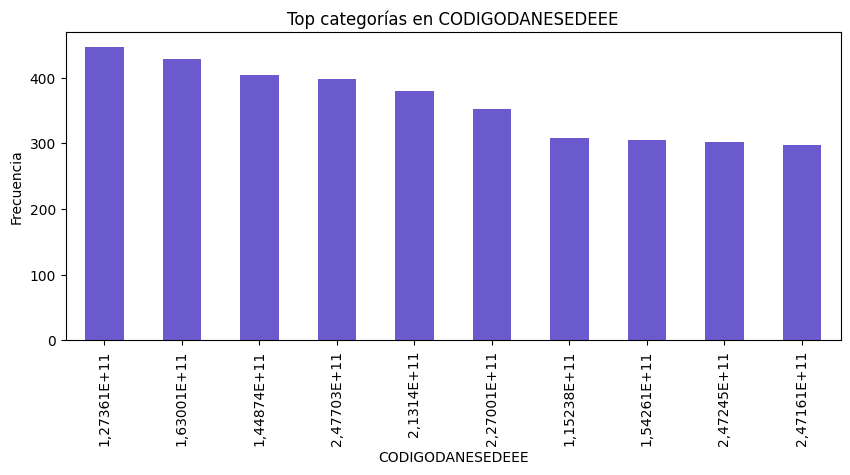

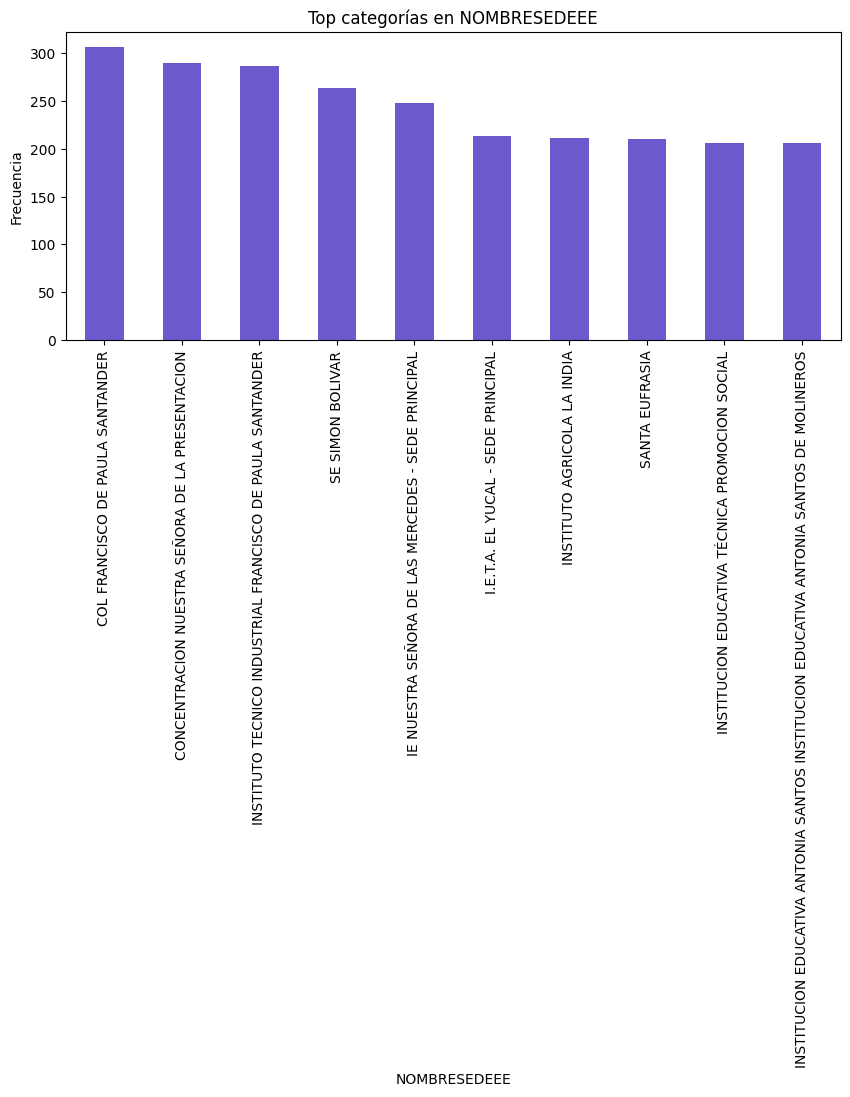

In [72]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols[:10]:  # limitar a 10 para no saturar
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind='bar', color='slateblue')
    plt.title(f"Top categorías en {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

###### ============================================================
#### FASE 2 
###### ============================================================

###### ============================================================
#### 2.1 NORMALIZACION DE DATO
###### ============================================================

In [73]:
def normalizar_nombre_columna(col):
    col = col.lower()
    col = ''.join(c for c in unicodedata.normalize('NFD', col)
                  if unicodedata.category(c) != 'Mn')
    col = re.sub(r'[^a-z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col)
    col = col.strip('_')
    return col

def normalizar_columnas_df(df):
    nuevas = []
    vistos = {}
    for col in df.columns:
        nuevo = normalizar_nombre_columna(col)
        if nuevo in vistos:
            vistos[nuevo] += 1
            nuevo = f"{nuevo}_{vistos[nuevo]}"
        else:
            vistos[nuevo] = 0
        nuevas.append(nuevo)
    df.columns = nuevas
    return df

df_modelo = normalizar_columnas_df(df.copy())


#df["CODIGODANEEE"] = df["CODIGODANEEE"].apply(lambda x: limpiar_codigo(x) + "059")
#df["CODIGODANESEDEEE"] = df["CODIGODANESEDEEE"].apply(lambda x: limpiar_codigo(x) + "059")


def corregir_categorias(df):
    # Sexo → m / f
    df['sexo'] = df['sexo'].str.upper().replace({
        'MASCULINO': 'M',
        'FEMENINO': 'F'
    })

    # Etnia → estandarizar
    df['pertenenciaetnica'] = df['pertenenciaetnica'].str.upper().replace({'NINGUN GRUPO ETNICO': 'NINGUNO'})
    df['divipolamunicipio'] = df['divipolamunicipio'].astype(str).str.zfill(5)    
    df['fechanacimientoddmmaaaa'] = pd.to_datetime(df['fechanacimientoddmmaaaa'], errors='coerce')
    df['fecharegisro'] = pd.to_datetime(df['fecharegisro'], errors='coerce', dayfirst=True)

    # Variables binarias → 1/0
    binarios_si_no = ['personacondiscapacidad']
    for col in binarios_si_no:
        df[col] = df[col].replace({'NO': 0, 'SI': 1})
    return df
df.columns = df.columns.str.strip().str.upper()
def tratar_nulos(df):
    # Moda para sexo
    df['sexo'] = df['sexo'].fillna(df['sexo'].mode()[0])

    # Mediana para grado escolar
    df['gradoescolar'] = df['gradoescolar'].fillna(df['gradoescolar'].median())

    # Eliminar registros sin centro de interés
    df = df[df['centrointeres'].notna()]

    return df

###### ============================================================
#### 3 CREACION TABLAS DIMENSIONES
###### ============================================================

In [74]:
#DIM ESTUDIANTE
dim_estudiante = df_modelo[[
    'numerodocumento',
    'sexo',
    'fechanacimientoddmmaaaa',
    'pertenenciaetnica',
    'campesino',
    'personacondiscapacidad',
    'poblacionmigrante',
    'gradoescolar'
]].drop_duplicates().reset_index(drop=True)

dim_estudiante.insert(0, 'id_estudiante', dim_estudiante.index + 1)


In [76]:
#DIM TIEMPO
dim_tiempo = df_modelo[['anio', 'fecharegisro']].drop_duplicates().reset_index(drop=True)
dim_tiempo.insert(0, 'id_tiempo', dim_tiempo.index + 1)

In [77]:
#DIM MUNICIPIO
dim_municipio = df_modelo[[
    'divipolamunicipio','departamentomunicipio','vereda','urbano_rural'
]].drop_duplicates().reset_index(drop=True)
dim_municipio.insert(0, 'id_municipio', dim_municipio.index + 1)

In [78]:
#DIM INSTITUCIÓN
dim_institucion = df_modelo[[
    'universidadejecutora','nombreee','codigodaneee',
    'codigodanesedeee','nombresedeee'
]].drop_duplicates().reset_index(drop=True)

dim_institucion.insert(0, 'id_institucion', dim_institucion.index + 1)


In [79]:
#DIM PROGRAMA
dim_programa = df_modelo[[
    'lineadeprograma','rutadeexperiencia','centrointeres','planeaciion'
]].drop_duplicates().reset_index(drop=True)

dim_programa.insert(0, 'id_programa', dim_programa.index + 1)


###### ============================================================
#### 3.2 Construcción de la tabla de hechos
###### ============================================================

In [80]:
fact = df_modelo.merge(
    dim_estudiante,
    on=[
        'numerodocumento','sexo','fechanacimientoddmmaaaa',
        'pertenenciaetnica','campesino','personacondiscapacidad',
        'poblacionmigrante','gradoescolar'
    ],
    how='left'
)

fact = fact.merge(
    dim_tiempo,
    on=['anio','fecharegisro'],   # así está en tu df_modelo
    how='left'
)

fact = fact.merge(
    dim_municipio,
    on=['divipolamunicipio','departamentomunicipio','vereda','urbano_rural'],
    how='left'
)

fact = fact.merge(
    dim_institucion,
    on=['universidadejecutora','nombreee','codigodaneee','codigodanesedeee','nombresedeee'],
    how='left'
)

fact = fact.merge(
    dim_programa,
    on=['lineadeprograma','rutadeexperiencia','centrointeres','planeaciion'],
    how='left'
)

# Detectar columna en minusculas para correcion y homogenizar los campos
id_cols = [c for c in fact.columns if c.lower().strip() == 'id']
if len(id_cols) == 1:
    fact = fact.rename(columns={id_cols[0]: 'id'})
else:
    print("Problema con columna ID:", id_cols)

# Detectar columnas de requerimientos
col_alim = [c for c in fact.columns if 'alimentacion' in c.lower()]
col_trans = [c for c in fact.columns if 'transporte' in c.lower()]

if len(col_alim) == 1:
    fact = fact.rename(columns={col_alim[0]: 'requiere_alimentacion'})
else:
    print("Problema con columna de alimentación:", col_alim)

if len(col_trans) == 1:
    fact = fact.rename(columns={col_trans[0]: 'requiere_transporte'})
else:
    print("Problema con columna de transporte:", col_trans)

In [81]:
#Seleccionar columnas finales de la tabla de hechos
fact_participacion = fact[[
    'id',
    'id_estudiante',
    'id_tiempo',
    'id_municipio',
    'id_institucion',
    'id_programa',
    'requiere_alimentacion',
    'requiere_transporte'
]].rename(columns={
    'id': 'id_registro_fuente'
})



###### ============================================================
#### Conexion a SQL 
###### ============================================================

Antes de correr el codigo se debe instalar la SQL Server Express en el Equipo 

In [83]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=INTEL\SQLEXPRESS;"
    "DATABASE=UNIR;"  
    "Trusted_Connection=yes;" 
)
cursor = conn.cursor()



Clean SQL codigo auxiliar para eliminar tablas - no Usar en Produccion

In [85]:
tabla = "dim_municipio" #cambiar aca le nombre de la tabla

# Buscar FKs que apunten a la tabla
cursor.execute(f"""
SELECT fk.name, tp.name AS tabla_padre
FROM sys.foreign_keys fk
INNER JOIN sys.tables tp ON fk.parent_object_id = tp.object_id
INNER JOIN sys.tables tr ON fk.referenced_object_id = tr.object_id
WHERE tr.name = '{tabla}';
""")
#================================
fks = cursor.fetchall()
# Eliminar cada FK encontrada
for fk_name, tabla_padre in fks:
    print(f"Eliminando FK {fk_name} en tabla {tabla_padre}")
    cursor.execute(f"ALTER TABLE {tabla_padre} DROP CONSTRAINT {fk_name};")
conn.commit()
#================================
cursor.execute("DROP TABLE IF EXISTS dim_municipio;")
conn.commit()



In [ ]:
cursor.close()
conn.close()

###### ============================================================
####   Creacion de Tablas
###### ============================================================

In [ ]:
cursor.execute("""
     IF OBJECT_ID('dim_estudiante') IS NULL
    CREATE TABLE dim_estudiante (
        ID_ESTUDIANTE INT IDENTITY(1,1) PRIMARY KEY,
        NUMERODOCUMENTO VARCHAR(50),
        SEXO VARCHAR(50),
        FECHANACIMIENTODDMMAAAA DATE,
        PERTENENCIAETNICA VARCHAR(50),
        CAMPESINO INT,
        PERSONACONDISCAPACIDAD VARCHAR(50),
        POBLACIONMIGRANTE INT,
        GRADOESCOLAR VARCHAR(50)
    )
    """)
conn.commit()


In [ ]:

cursor.execute("""
     IF OBJECT_ID('dim_tiempo') IS NULL
  CREATE TABLE dbo.dim_tiempo (
    id_tiempo INT IDENTITY(1,1) PRIMARY KEY,
    anio INT,
    fecharegisro VARCHAR(50)
   );
    """)
conn.commit()

In [86]:

cursor.execute("""
     IF OBJECT_ID('dim_municipio') IS NULL
  CREATE TABLE dbo.dim_municipio (
    id_municipio INT IDENTITY(1,1) PRIMARY KEY,
    divipolamunicipio VARCHAR(50),
    departamentomunicipio VARCHAR(200),
    vereda VARCHAR(200),
    urbano_rural VARCHAR(50)
);

    """)
conn.commit()

In [ ]:
cursor.execute("""
     IF OBJECT_ID('dim_institucion') IS NULL
  CREATE TABLE dbo.dim_institucion (
    id_institucion INT IDENTITY(1,1) PRIMARY KEY,
    universidadejecutora VARCHAR(200),
    nombreee VARCHAR(200),
    codigodaneee VARCHAR(50),
    codigodanesedeee VARCHAR(50),
    nombresedeee VARCHAR(200)
);

    """)
conn.commit()

In [ ]:
cursor.execute("""
     IF OBJECT_ID('dim_programa') IS NULL
  CREATE TABLE dbo.dim_programa (
    id_programa INT IDENTITY(1,1) PRIMARY KEY,
    lineadeprograma VARCHAR(200),
    rutadeexperiencia VARCHAR(200),
    centrointeres VARCHAR(200),
    planeaciion VARCHAR(200)
);

    """)
conn.commit()

In [ ]:
cursor.execute("""
     IF OBJECT_ID('fact_participacion') IS NULL
    CREATE TABLE dbo.fact_participacion (
    id_fact INT IDENTITY(1,1) PRIMARY KEY,
    id_registro_fuente INT,
    id_estudiante INT,
    id_tiempo INT,
    id_municipio INT,
    id_institucion INT,
    id_programa INT,
    requiere_alimentacion INT,
    requiere_transporte INT,
    FOREIGN KEY (id_estudiante) REFERENCES dbo.dim_estudiante(id_estudiante),
    FOREIGN KEY (id_tiempo) REFERENCES dbo.dim_tiempo(id_tiempo),
    FOREIGN KEY (id_municipio) REFERENCES dbo.dim_municipio(id_municipio),
    FOREIGN KEY (id_institucion) REFERENCES dbo.dim_institucion(id_institucion),
    FOREIGN KEY (id_programa) REFERENCES dbo.dim_programa(id_programa)
);
    """)
conn.commit()

###### ============================================================
#### Insertar Datos del Archivo csv a Sql Server
###### ============================================================

Insert Dim_Estudiante

In [ ]:
# Insertar dimensiones


dim_estudiante['fechanacimientoddmmaaaa'] = pd.to_datetime(
    dim_estudiante['fechanacimientoddmmaaaa'],
    format='%d%m%Y',
    errors='coerce'
)

for _, row in dim_estudiante.iterrows():
    cursor.execute("""
        INSERT INTO dim_estudiante (
            numerodocumento, sexo, fechanacimientoddmmaaaa,
            pertenenciaetnica, campesino, personacondiscapacidad,
            poblacionmigrante, gradoescolar
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, tuple(row[1:])) 
conn.commit()


#inserta solo 1000 registros
#for _, row in dim_estudiante.head(1000).iterrows():
#    cursor.execute("""
#        INSERT INTO dim_estudiante (
#            numerodocumento, sexo, fechanacimientoddmmaaaa,
#            pertenenciaetnica, campesino, personacondiscapacidad,
#            poblacionmigrante, gradoescolar
#        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
#    """, tuple(row[1:]))
#conn.commit()



Insert Dim_Tiempo

In [ ]:
for _, row in dim_tiempo.iterrows():
    cursor.execute("""
        INSERT INTO dim_tiempo (
            anio, fecharegisro
        ) VALUES (?, ?)
    """, tuple(row[1:])) 
conn.commit()


Insert Dim_Municipio

In [87]:
for _, row in dim_municipio.iterrows():
    cursor.execute("""
        INSERT INTO dim_municipio (
            divipolamunicipio, departamentomunicipio,
            vereda, urbano_rural
        ) VALUES (?, ?, ?, ?)
    """, tuple(row[1:]))
conn.commit()


Insert Dim Institucion

In [ ]:
for _, row in dim_institucion.iterrows():
    cursor.execute("""
        INSERT INTO dim_institucion (
            universidadejecutora, nombreee,
            codigodaneee, codigodanesedeee, nombresedeee
        ) VALUES ( ?, ?, ?, ?, ?)
    """, tuple(row[1:])) 
conn.commit()

Insert Dim_Programa

In [ ]:
for _, row in dim_programa.iterrows():
    cursor.execute("""
        INSERT INTO dim_programa (
            lineadeprograma, rutadeexperiencia,
            centrointeres, planeaciion
        ) VALUES (?, ?, ?, ?)
    """, tuple(row[1:])) 
conn.commit()


Insert Keys_FactParticipacion

In [ ]:
for _, row in fact.iterrows():
    cursor.execute("""
        INSERT INTO fact_participacion (
            id_estudiante, id_tiempo, id_municipio,
            id_institucion, id_programa
        ) VALUES (?, ?, ?, ?, ?)
    """, (
        row['id_estudiante'],
        row['id_tiempo'],
        row['id_municipio'],
        row['id_institucion'],
        row['id_programa']
    ))
conn.commit()

Total Registros Insertados en cada Tabla

In [ ]:
tablas = [
    "dim_estudiante",
    "dim_tiempo",
    "dim_municipio",
    "dim_institucion",
    "dim_programa",
    "fact_participacion"
]

for tabla in tablas:
    cursor.execute(f"SELECT COUNT(*) FROM {tabla};")
    count = cursor.fetchone()[0]
    print(f"{tabla}: {count} registros")

cursor.close()
conn.close()
